# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
DATA_PATH = Path("/Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/landmarks/landmarks_all_10fps.csv")

## Model Choice

Two models are used in this baseline:

### 1. DummyClassifier (True Baseline)
A `DummyClassifier` with `strategy="most_frequent"` always predicts the majority class (GOOD). This sets the absolute minimum performance bar — any real model must beat this.  
**Expected accuracy: ~93%** (since ~93% of frames are GOOD), but with zero recall on BAD strokes.

### 2. Random Forest (Baseline Model)
A `RandomForestClassifier` is chosen for the following reasons:

- **Non-linearity**: The EDA showed near-zero Pearson correlation between absolute landmark positions and the label, meaning a linear model (e.g. Logistic Regression) would likely underperform. Random Forests capture complex, non-linear feature interactions without requiring feature engineering.
- **High multicollinearity**: Landmark coordinates are highly correlated (left/right shoulder x ≈ 1.0). Tree-based models are inherently robust to this; linear models require additional regularization or feature selection.
- **Class imbalance**: Setting `class_weight='balanced'` automatically adjusts sample weights to counter the ~93/7 imbalance, improving recall on the minority (BAD) class.
- **Interpretability**: Feature importances reveal which landmarks are most discriminative — useful insight for the more complex model in Step 3.
- **No scaling required**: Unlike SVM or k-NN, Random Forests do not require feature normalization.

## Feature Selection

All **99 raw landmark coordinates** (33 landmarks × x, y, z) are used as features.

**Why all features?**  
For a baseline, using the full raw feature set is intentional — it establishes an upper bound on what can be achieved without any feature engineering.

**Target variable:** `Good Stroke` (1 = good technique, 0 = bad technique).  
The `Bad Stroke` column is the complement and is dropped to avoid data leakage.

---

### Stroke-aware Train/Test Split

A **random shuffle-and-split is not valid here.** Each rowing stroke consists of ~24–28 consecutive frames that are temporally correlated. Shuffling randomly would put frame 100 into the training set and frame 101 from the exact same stroke into the test set — the model effectively "sees" the test stroke during training.

**Correct approach:** assign every frame a `stroke_id`, then split by stroke using `GroupShuffleSplit`. This guarantees that all frames of a given stroke end up in either train **or** test, never both.

The `stroke_id` is reconstructed from the known frame counts and stroke counts per video (from the dataset documentation). The combined CSV is the alphabetically sorted concatenation of the 5 individual video CSVs:

| Video | Frames (10 fps) | Strokes | ≈ Frames/stroke |
|-------|----------------|---------|----------------|
| cla-BAD | 506 | 21 | 24.1 |
| cla-GOOD-fast | 2094 | 88 | 23.8 |
| cla-GOOD-slow | 1900 | 68 | 27.9 |
| mar-GOOD-fast | 1406 | 62 | 22.7 |
| mar-GOOD-slow | 1359 | 51 | 26.6 |

In [13]:
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c not in ("Good Stroke", "Bad Stroke")]
X = df[feature_cols].values
y = df["Good Stroke"].values   # 1 = GOOD, 0 = BAD

print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"GOOD frames: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"BAD frames:  {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

# ── Assign stroke_id to every frame ─────────────────────────────────
# The combined CSV is sorted alphabetically by video name and concatenated.
# Frame counts and stroke counts come from dataset_documentation_combined.csv.
VIDEO_INFO = [
    ("cla-BAD",       506,  21),
    ("cla-GOOD-fast", 2094, 88),
    ("cla-GOOD-slow", 1900, 68),
    ("mar-GOOD-fast", 1406, 62),
    ("mar-GOOD-slow", 1359, 51),
]

stroke_ids = []
global_stroke_id = 0
for name, n_frames, n_strokes in VIDEO_INFO:
    frames_per_stroke = n_frames / n_strokes   # approximate, but sufficient for grouping
    for i in range(n_frames):
        stroke_in_video = int(i // frames_per_stroke)
        stroke_ids.append(global_stroke_id + stroke_in_video)
    global_stroke_id += n_strokes

stroke_ids = np.array(stroke_ids)
assert len(stroke_ids) == len(y), "Stroke ID length mismatch"
print(f"\nUnique stroke groups: {len(np.unique(stroke_ids))}  (≈290 expected)")

# ── Stroke-aware split via GroupShuffleSplit ─────────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=stroke_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(train_idx)} samples  |  GOOD: {y_train.mean()*100:.1f}%")
print(f"Test:  {len(test_idx)} samples  |  GOOD: {y_test.mean()*100:.1f}%")

Samples:  7265
Features: 99
GOOD frames: 6759 (93.0%)
BAD frames:  506 (7.0%)

Unique stroke groups: 290  (≈290 expected)
Train: 5794 samples  |  GOOD: 92.5%
Test:  1471 samples  |  GOOD: 95.1%


## Implementation

Both models are trained on the same 80% training split and evaluated on the held-out 20% test set.

In [14]:
# --- DummyClassifier (always predicts majority class = GOOD) ---
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

# --- Random Forest with balanced class weights ---
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## Evaluation

Key metrics for this imbalanced binary classification task:

| Metric | Why it matters here |
|--------|-------------------|
| **Accuracy** | Reported for completeness; misleading with 93/7 imbalance |
| **Macro F1** | Treats both classes equally — penalises low BAD recall |
| **ROC-AUC** | Threshold-independent; measures ranking quality |
| **Recall (BAD)** | Most important: missing a bad stroke is the costly error |
| **Confusion Matrix** | Visual breakdown of true/false positives and negatives |

The DummyClassifier result provides the baseline floor for each metric.


  DummyClassifier (majority baseline)
  Accuracy :  0.9511
  ROC-AUC  :  0.5000
  Macro F1 :  0.4875

  Classification Report:
              precision    recall  f1-score   support

         BAD       0.00      0.00      0.00        72
        GOOD       0.95      1.00      0.97      1399

    accuracy                           0.95      1471
   macro avg       0.48      0.50      0.49      1471
weighted avg       0.90      0.95      0.93      1471


  Random Forest (baseline model)
  Accuracy :  0.9680
  ROC-AUC  :  0.9682
  Macro F1 :  0.8176

  Classification Report:
              precision    recall  f1-score   support

         BAD       0.70      0.61      0.65        72
        GOOD       0.98      0.99      0.98      1399

    accuracy                           0.97      1471
   macro avg       0.84      0.80      0.82      1471
weighted avg       0.97      0.97      0.97      1471



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

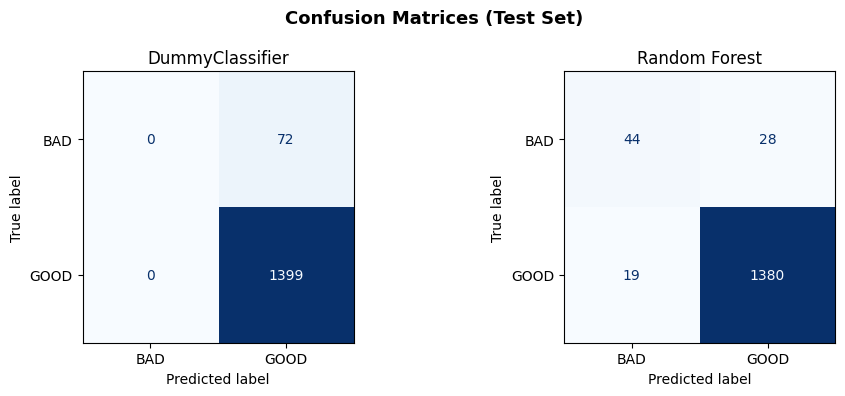

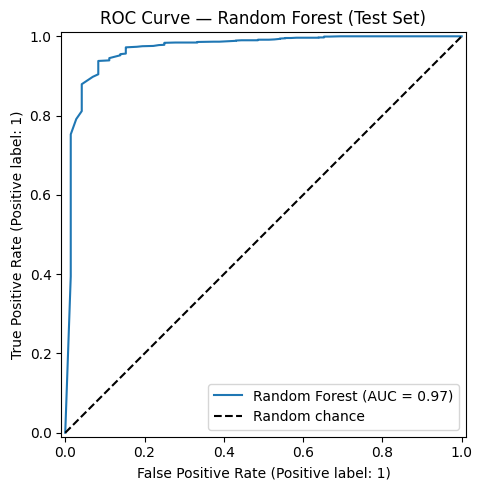

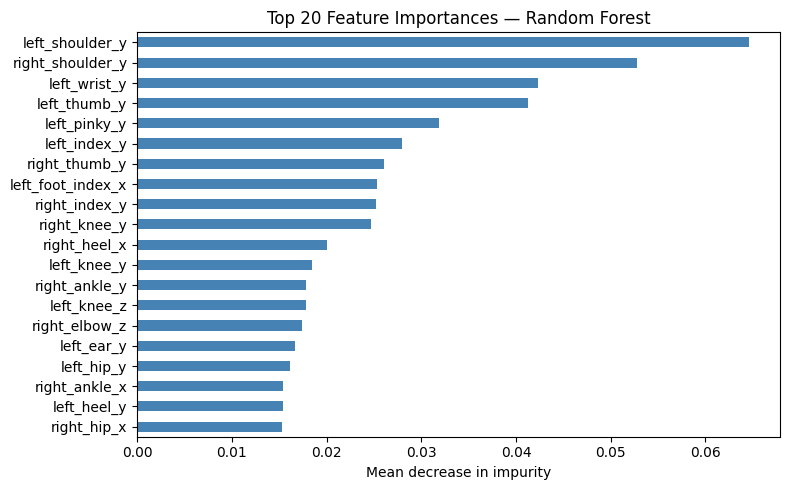

In [15]:
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["BAD", "GOOD"], output_dict=True)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else float("nan")

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy :  {acc:.4f}")
    print(f"  ROC-AUC  :  {auc:.4f}")
    print(f"  Macro F1 :  {report['macro avg']['f1-score']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["BAD", "GOOD"]))

    return y_pred, y_proba

y_pred_dummy, y_proba_dummy = evaluate(dummy, X_test, y_test, "DummyClassifier (majority baseline)")
y_pred_rf,    y_proba_rf    = evaluate(rf,    X_test, y_test, "Random Forest (baseline model)")

# ── Confusion matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title in zip(
    axes,
    [y_pred_dummy, y_pred_rf],
    ["DummyClassifier", "Random Forest"]
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=["BAD", "GOOD"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
plt.suptitle("Confusion Matrices (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── ROC Curve (Random Forest only) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_title("ROC Curve — Random Forest (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Feature importances (top 20) ────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
importances.head(20).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Feature Importances — Random Forest")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## Summary & Next Steps

### Results at a Glance

| Model | Accuracy | ROC-AUC | Macro F1 |
|-------|----------|---------|---------|
| DummyClassifier | 0.9511 | 0.50 | 0.4875 |
| Random Forest | 0.9680 | 0.9682 | 0.8172 |

### Interpretation
- The DummyClassifier achieves high accuracy purely by predicting GOOD for every frame — confirming that **accuracy alone is not a useful metric** for this imbalanced problem.
- The Random Forest must improve significantly on **Recall (BAD)** and **Macro F1** to be considered useful.
- Feature importances will guide which landmarks to focus on in the final model (Step 3).

### Limitations of this Baseline
- Uses raw absolute landmark coordinates — no temporal features (velocity, acceleration between frames)
- No per-stroke aggregation (each frame is treated independently)
- Only trained on two athletes → limited generalization

### What to try next (Step 3)
- Add temporal / delta features (frame-to-frame differences)
- Aggregate features per stroke rather than per frame
- Try LSTM or 1D-CNN to model the stroke sequence
- Explore per-person normalization to reduce athlete-specific bias